# IOT Data Exploration
Reads all sources from `Data`, resamples to 10-minute windows, imputes, and visualises.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

DATA = 'Data/'

## 1. Load raw sources

In [66]:
START = '2026-02-28'
END   = '2026-03-14'

def load(filename, **kwargs):
    df = pd.read_csv(DATA + filename, parse_dates=['created_at'], **kwargs)
    df = df.rename(columns=str.strip)
    df = df.set_index('created_at').sort_index()
    df.index = df.index.tz_convert('UTC')
    return df

scd30   = load('scd30_sensor_readings.csv')[START:END]
weather = load('weather_api_readings.csv')[START:END]
fan     = load('fan_control_history.csv')[START:END]
occ     = load('occupancy_detection_readings.csv')[START:END]
conc    = load('logged_concerntration_readings.csv')[START:END]
win     = load('logged_window_status_history.csv')[START:END].rename(columns={'window_status': 'window_open'})



print(f"SCD30    : {len(scd30):>6,} rows  {scd30.index[0].date()} to {scd30.index[-1].date()}")
print(f"Weather  : {len(weather):>6,} rows")
print(f"Fan      : {len(fan):>6,} rows")
print(f"Occupancy: {len(occ):>6,} rows")
print(f"Window   : {len(win):>6,} events")
print(f"Conc.    : {len(conc):>6,} readings")

SCD30    : 76,550 rows  2026-02-28 to 2026-03-14
Weather  :  3,223 rows
Fan      :  3,906 rows
Occupancy:  3,788 rows
Window   :     51 events
Conc.    :  3,788 readings


## System Reliability & Completeness

In [67]:
days = (scd30.index[-1] - scd30.index[0]).total_seconds() / 86400

exp_scd30 = int(days * 5670)
inv_co2   = (scd30['indoor_co2_ppm'] <= 300).sum()
exp_wx    = int(days * 24 * 10)
oob       = ((occ['number_of_occupants'] < 0) | (occ['number_of_occupants'] > 3)).sum()

total_s      = days * 86400
scd30_down   = scd30.index.to_series().diff().dt.total_seconds().pipe(lambda s: s[s > 60].sum())
weather_down = weather.index.to_series().diff().dt.total_seconds().pipe(lambda s: s[s > 900].sum())

pd.DataFrame([
    {'Source': 'SCD30 (sensor)', 'Expected': exp_scd30, 'Received': len(scd30), 'Completeness %': f"{len(scd30)/exp_scd30*100:.1f}", 'Uptime %': f"{(1 - scd30_down/total_s)*100:.1f}", 'Invalid': f"{inv_co2} CO₂ ≤300 ppm ({inv_co2/len(scd30)*100:.2f}%)"},
    {'Source': 'Weather (API)',  'Expected': exp_wx,    'Received': len(weather),'Completeness %': f"{len(weather)/exp_wx*100:.1f}",  'Uptime %': f"{(1 - weather_down/total_s)*100:.1f}", 'Invalid': '—'},
    {'Source': 'Occupancy',      'Expected': '—',       'Received': len(occ),   'Completeness %': '—',                                'Uptime %': '—',      'Invalid': f"{oob} out-of-range (not 0-3)"},
]).set_index('Source')

,Expected,Received,Completeness %,Uptime %,Invalid
Source,,,,,
SCD30 (sensor),82100,76550,93.2,99.8,6 CO₂ ≤300 ppm (0.01%)
Weather (API),3475,3223,92.7,97.4,—
Occupancy,—,3788,—,—,0 out-of-range (not 0-3)


## 2. Data Cleaning

In [68]:
# Remove physically impossible CO2 readings. Readings should never be less th 400ppm (outdoors)
scd30 = scd30[scd30['indoor_co2_ppm'] > 300]

conc['concentration_level'] = pd.to_numeric(conc['concentration_level'], errors='coerce') # since the readings are sparse, we want to drop empty rows
conc = conc.dropna(subset=['concentration_level'])

conc.head()



,concentration_level
created_at,
2026-02-28 02:35:45+00:00,1.0
2026-02-28 11:33:59+00:00,9.0
2026-02-28 11:53:09+00:00,9.0
2026-02-28 22:47:54+00:00,2.0
2026-03-01 12:36:47+00:00,8.0


## 3. Resample to 10-minute windows

In [69]:
FREQ = '10min'

# Continuous sensors — mean per window
scd30_r   = scd30.resample(FREQ).mean()
weather_r = weather.resample(FREQ).mean()

# Fan — was it on at any point in the window?
fan_r = fan.resample(FREQ).max()

# Occupancy — round mean (preserves integer-like values)
occ_r = occ.resample(FREQ).mean().round()

# Window status — forward-fill from last known event
win_r = win.resample(FREQ).last().ffill().fillna(0)

# Concentration — mean of any readings in window (sparse, mostly NaN)
conc_r = conc.resample(FREQ).mean()

# Merge everything on a shared 10-min index
df = (scd30_r
      .join(weather_r, how='outer')
      .join(fan_r, how='outer')
      .join(occ_r, how='outer')
      .join(win_r, how='outer')
      .join(conc_r, how='outer')
)

# Trim to the period all sensors are active
df = df.loc['2026-02-26':'2026-03-14']

print(f"Master df: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns  : {list(df.columns)}")

Master df: 2086 rows × 9 columns
Columns  : ['indoor_co2_ppm', 'indoor_humidity_percent', 'indoor_temp_c', 'outdoor_temp_c', 'outdoor_humidity_percent', 'fan_activation', 'number_of_occupants', 'window_open', 'concentration_level']


## 4. Imputation

In [70]:
print("Missing values before imputation:")
print(df.isna().sum().to_string())

# Continuous sensors, linear interpolation, limit gap to 2 hours
for col in ['indoor_co2_ppm', 'indoor_temp_c', 'indoor_humidity_percent',
            'outdoor_temp_c', 'outdoor_humidity_percent']:
    df[col] = df[col].interpolate(method='time', limit=12)  # 12 × 10min = 2h

# Fan and occupancy, forward fill short gaps, then fill remaining with 0
for col in ['fan_activation', 'number_of_occupants']:
    df[col] = df[col].ffill(limit=3).fillna(0)

# Window , already forward-filled; fill any leading NaN as closed
df['window_open'] = df['window_open'].ffill().fillna(0)

# Concentration, leave sparse (NaN between readings is intentional)

print("\nMissing values after imputation:")
print(df.isna().sum().to_string())

Missing values before imputation:
indoor_co2_ppm                 0
indoor_humidity_percent        0
indoor_temp_c                  0
outdoor_temp_c                68
outdoor_humidity_percent      68
fan_activation                11
number_of_occupants         1454
window_open                   76
concentration_level         2027

Missing values after imputation:
indoor_co2_ppm                 0
indoor_humidity_percent        0
indoor_temp_c                  0
outdoor_temp_c                 0
outdoor_humidity_percent       0
fan_activation                 0
number_of_occupants            0
window_open                    0
concentration_level         2027


## 5. Summary statistics

In [71]:
df.drop(columns='concentration_level').describe().round(2)

,indoor_co2_ppm,indoor_humidity_percent,indoor_temp_c,outdoor_temp_c,outdoor_humidity_percent,fan_activation,number_of_occupants,window_open
count,2086.00,2086.00,2086.00,2086.00,2086.00,2086.00,2086.00,2086.00
mean,891.38,53.25,22.26,8.61,76.78,0.33,0.61,0.22
std,236.54,3.35,0.68,2.32,10.78,0.47,1.00,0.42
min,468.14,38.01,20.58,3.00,41.50,0.00,0.00,0.00
25%,707.64,51.57,21.89,7.00,71.00,0.00,0.00,0.00
50%,887.73,53.21,22.28,8.40,78.00,0.00,0.00,0.00
75%,1036.83,54.94,22.54,10.15,85.00,1.00,1.00,0.00
max,1988.85,63.69,26.91,15.40,96.00,1.00,3.00,1.00


## 6. Full time-series overview

In [72]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})

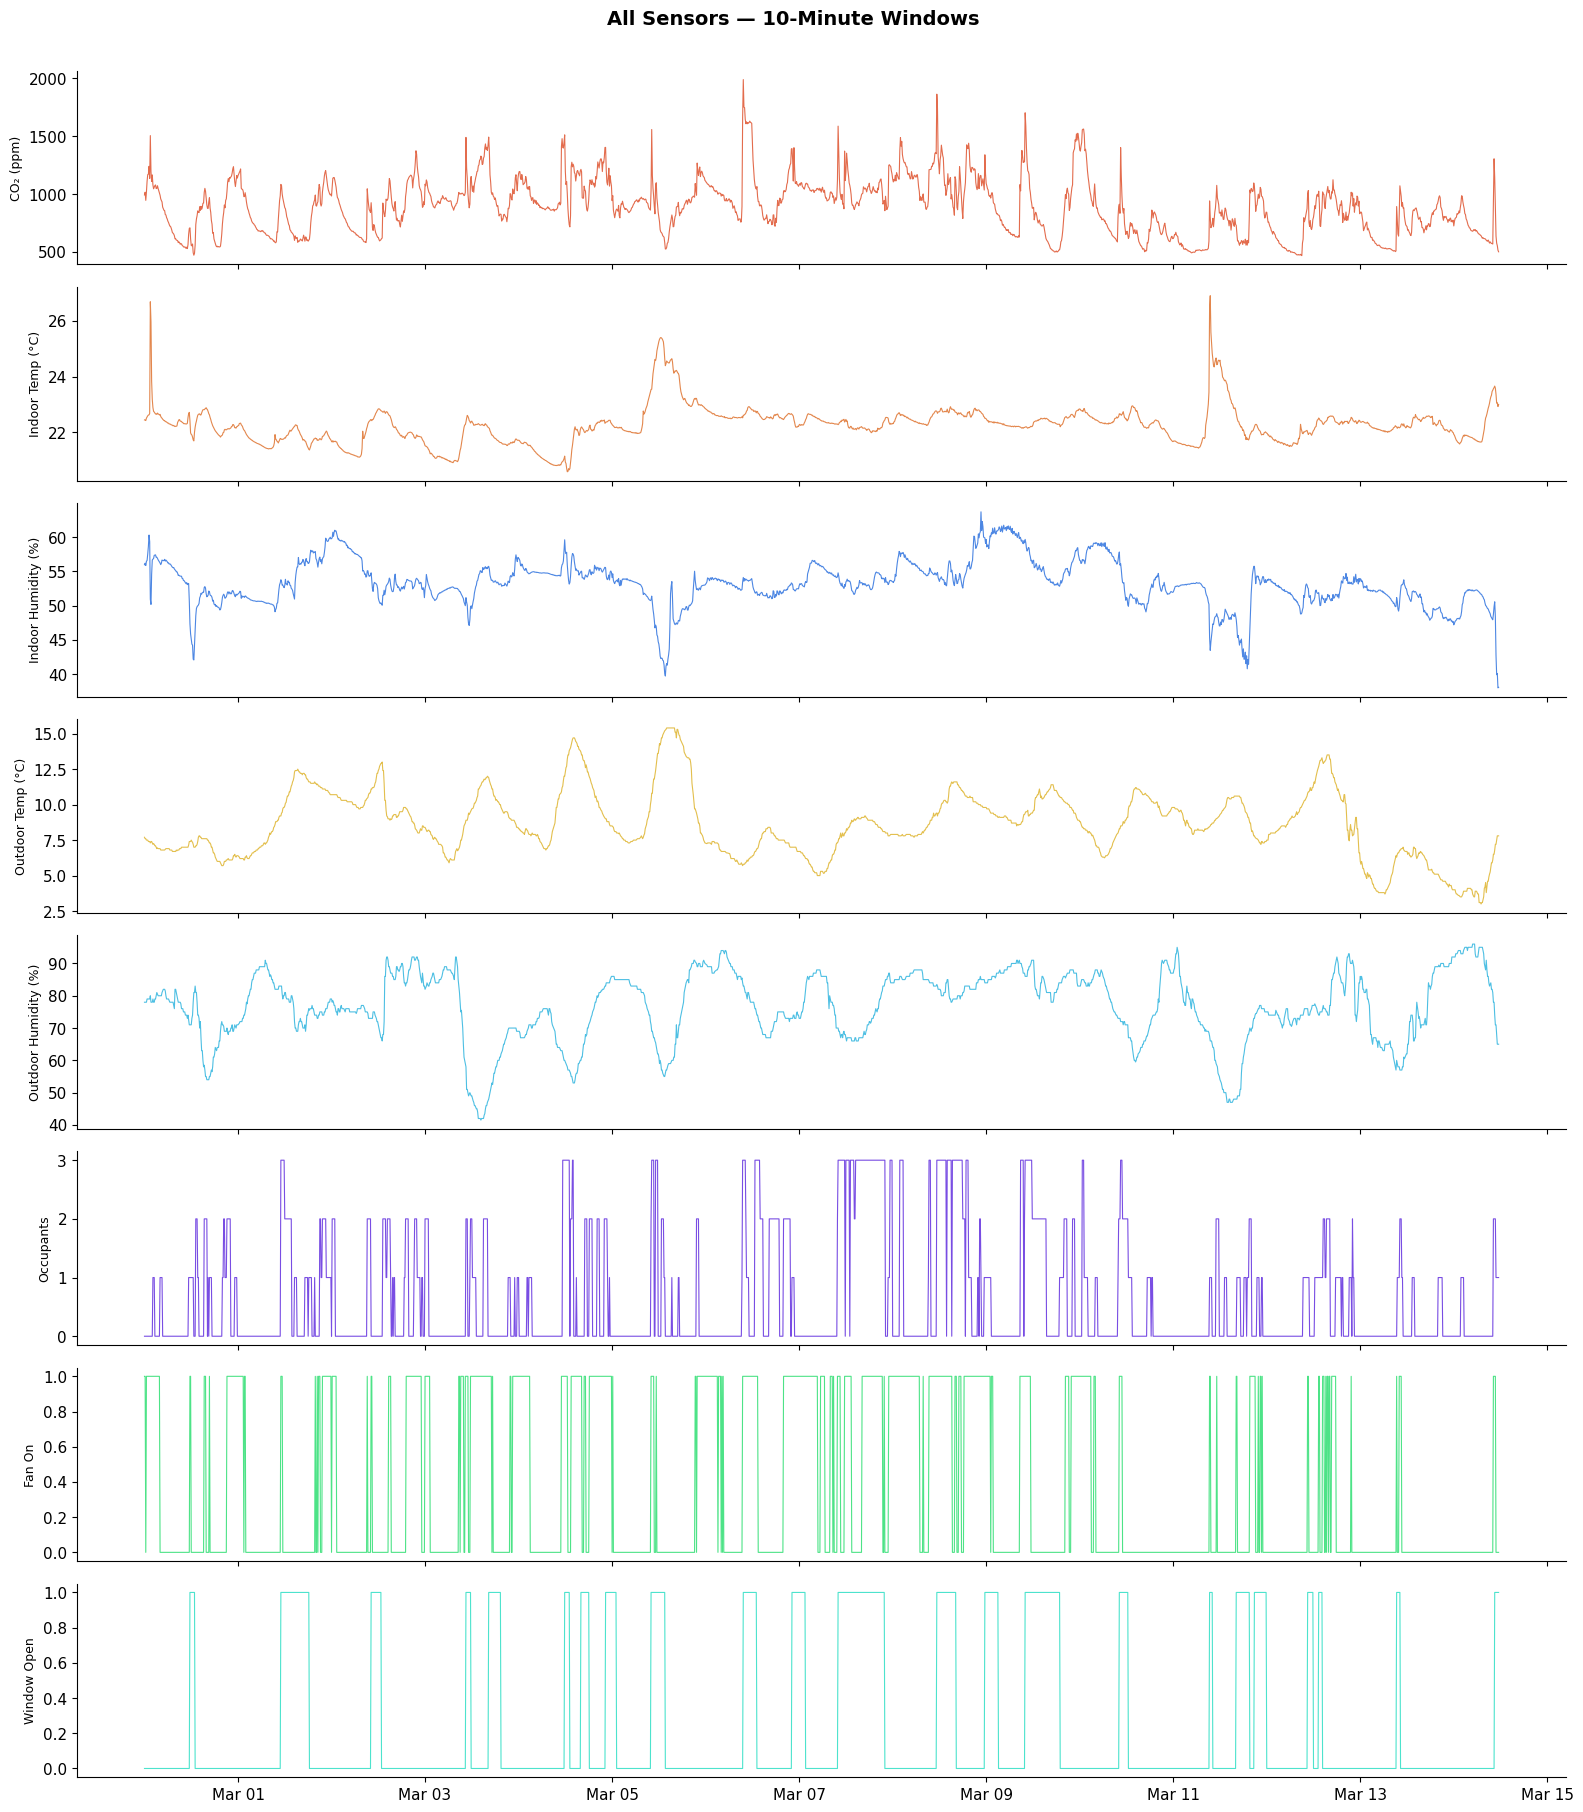

In [73]:
cols = [
    ('indoor_co2_ppm',          'CO₂ (ppm)',           '#e05c3a'),
    ('indoor_temp_c',           'Indoor Temp (°C)',     '#e07a3a'),
    ('indoor_humidity_percent', 'Indoor Humidity (%)',  '#3a7ae0'),
    ('outdoor_temp_c',          'Outdoor Temp (°C)',    '#e0b83a'),
    ('outdoor_humidity_percent','Outdoor Humidity (%)','#3ab8e0'),
    ('number_of_occupants',     'Occupants',            '#6a3ae0'),
    ('fan_activation',          'Fan On',               '#3ae07a'),
    ('window_open',             'Window Open',          '#3ae0c8'),
]

fig, axes = plt.subplots(len(cols), 1, figsize=(16, 18), sharex=True)
fig.suptitle('All Sensors — 10-Minute Windows', fontsize=14, fontweight='bold', y=1.005)

for ax, (col, label, colour) in zip(axes, cols):
    ax.plot(df.index, df[col], color=colour, linewidth=0.8, alpha=0.9)
    ax.set_ylabel(label, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()

## 7. CO₂ in detail — with window & fan overlaid

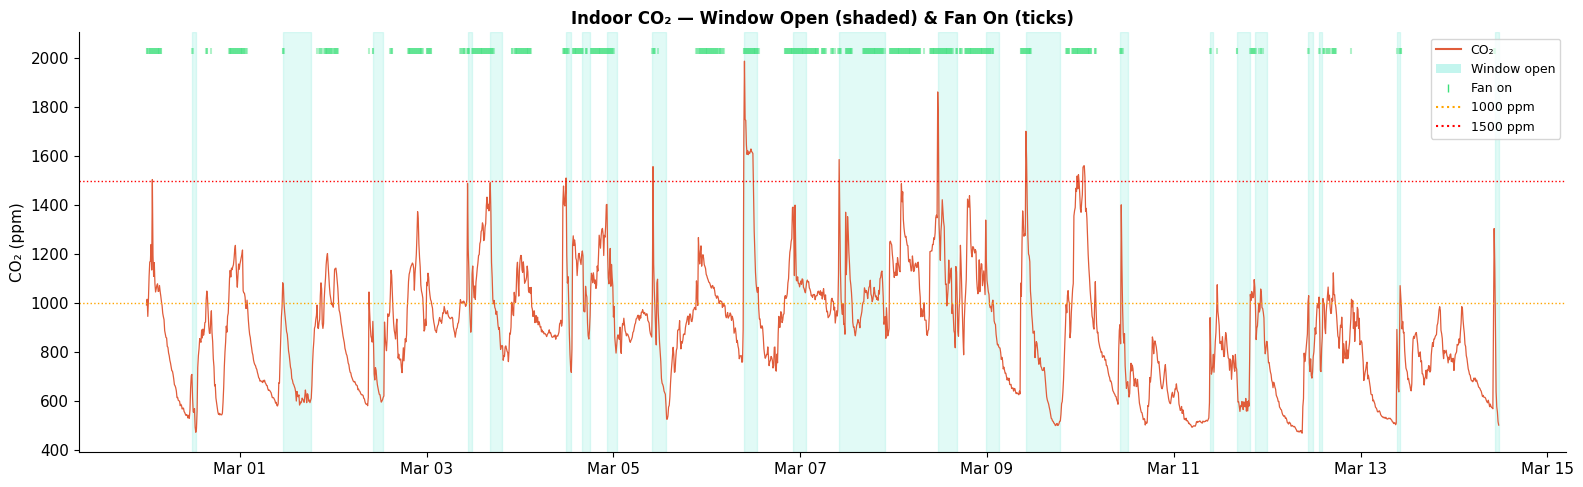

In [74]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df.index, df['indoor_co2_ppm'], color='#e05c3a', linewidth=0.9, label='CO₂')


win_open = df['window_open'] == 1
starts = df.index[win_open & ~win_open.shift(1).fillna(False)]
ends   = df.index[win_open & ~win_open.shift(-1).fillna(False)]
for start, end in zip(starts, ends):
    ax.axvspan(start, end, alpha=0.15, color='#3ae0c8')

# Mark fan-on periods with small ticks near the top
fan_on = df[df['fan_activation'] == 1]
co2_max = df['indoor_co2_ppm'].max()
ax.scatter(fan_on.index, [co2_max * 1.02] * len(fan_on),
           marker='|', s=20, color='#3ae07a', alpha=0.4)

ax.axhline(1000, color='orange', linestyle=':', linewidth=1, label='1000 ppm')
ax.axhline(1500, color='red',    linestyle=':', linewidth=1, label='1500 ppm')
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('Indoor CO₂ — Window Open (shaded) & Fan On (ticks)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

from matplotlib.patches import Patch
handles = [plt.Line2D([0],[0],color='#e05c3a',label='CO₂'),
           Patch(facecolor='#3ae0c8',alpha=0.3,label='Window open'),
           plt.Line2D([0],[0],marker='|',color='#3ae07a',linestyle='None',label='Fan on'),
           plt.Line2D([0],[0],color='orange',linestyle=':',label='1000 ppm'),
           plt.Line2D([0],[0],color='red',linestyle=':',label='1500 ppm')]
ax.legend(handles=handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

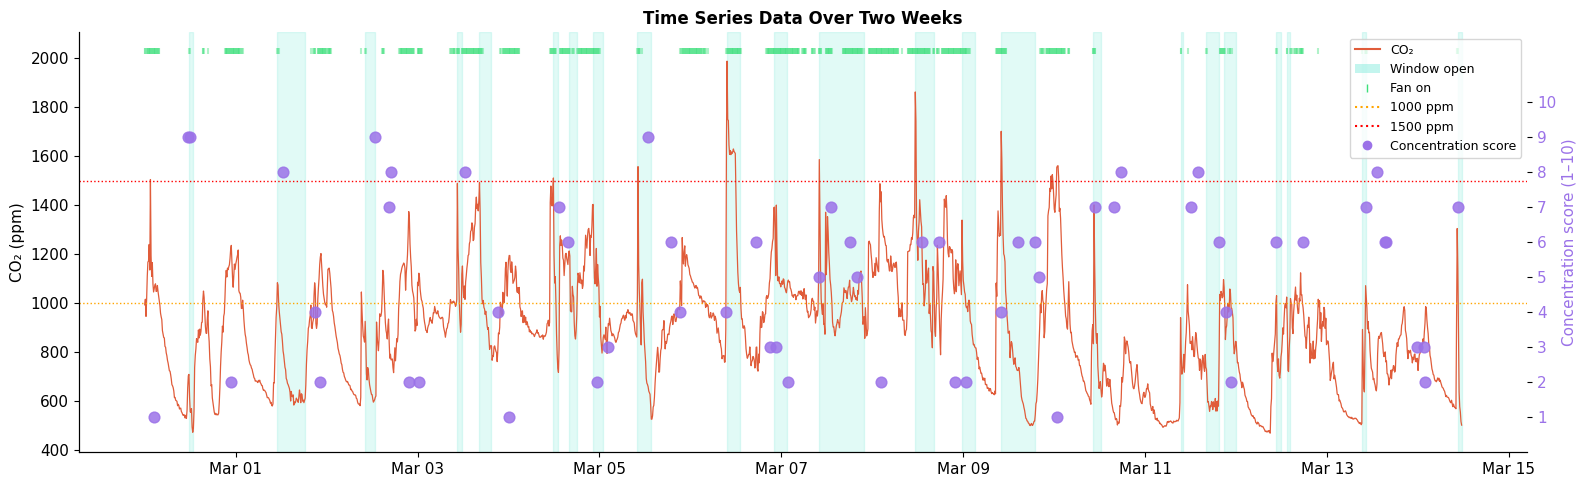

In [75]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df.index, df['indoor_co2_ppm'], color='#e05c3a', linewidth=0.9, label='CO₂')


win_open = df['window_open'] == 1
starts = df.index[win_open & ~win_open.shift(1).fillna(False)]
ends   = df.index[win_open & ~win_open.shift(-1).fillna(False)]
for start, end in zip(starts, ends):
    ax.axvspan(start, end, alpha=0.15, color='#3ae0c8')


fan_on = df[df['fan_activation'] == 1]
co2_max = df['indoor_co2_ppm'].max()
ax.scatter(fan_on.index, [co2_max * 1.02] * len(fan_on),
           marker='|', s=20, color='#3ae07a', alpha=0.4)

ax.axhline(1000, color='orange', linestyle=':', linewidth=1)
ax.axhline(1500, color='red',    linestyle=':', linewidth=1)
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('Time Series Data Over Two Weeks')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))


ax2 = ax.twinx()
conc_pts = df[df['concentration_level'].notna()]
sc = ax2.scatter(conc_pts.index, conc_pts['concentration_level'],
                 color='#9b72e8', s=60, zorder=5, alpha=0.85, label='Concentration score')
ax2.set_ylabel('Concentration score (1–10)', color='#9b72e8')
ax2.tick_params(axis='y', labelcolor='#9b72e8')
ax2.set_ylim(0, 12)
ax2.set_yticks(range(1, 11))
ax.grid(False)
ax2.grid(False)

from matplotlib.patches import Patch
handles = [plt.Line2D([0],[0],color='#e05c3a',label='CO₂'),
           Patch(facecolor='#3ae0c8',alpha=0.3,label='Window open'),
           plt.Line2D([0],[0],marker='|',color='#3ae07a',linestyle='None',label='Fan on'),
           plt.Line2D([0],[0],color='orange',linestyle=':',label='1000 ppm'),
           plt.Line2D([0],[0],color='red',linestyle=':',label='1500 ppm'),
           plt.Line2D([0],[0],marker='o',color='#9b72e8',linestyle='None',label='Concentration score')]
ax.legend(handles=handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


## 8. Average daily patterns (by hour)

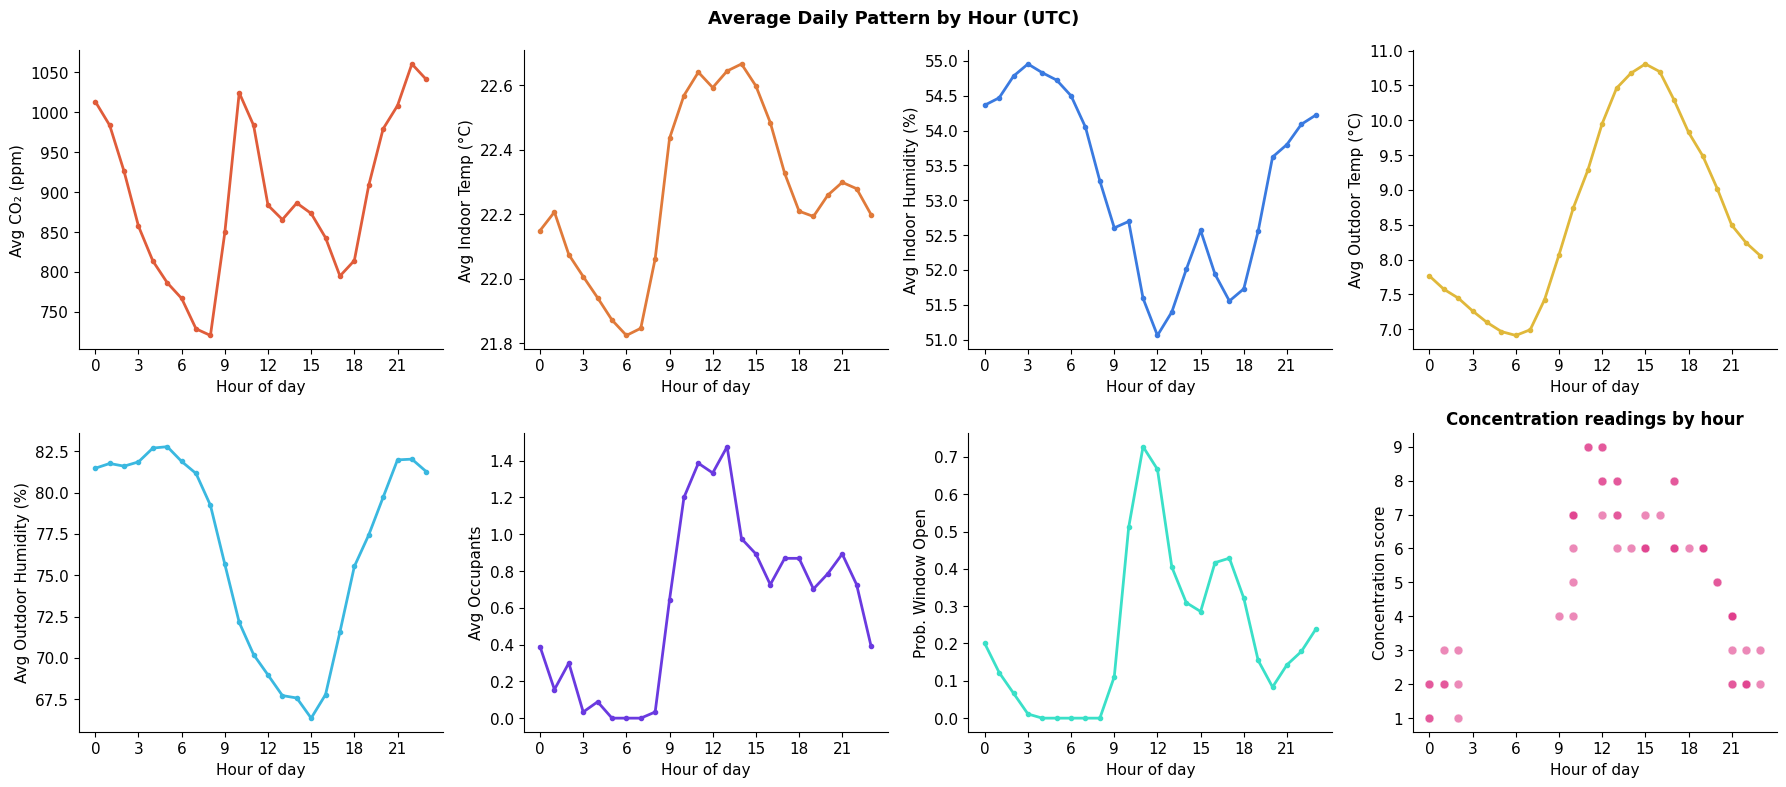

In [76]:

hourly = df.copy()
hourly['hour'] = hourly.index.hour
by_hour = hourly.groupby('hour')[[
    'indoor_co2_ppm', 'indoor_temp_c', 'indoor_humidity_percent',
    'outdoor_temp_c', 'outdoor_humidity_percent',
    'number_of_occupants', 'window_open'
]].mean()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Average Daily Pattern by Hour (UTC)', fontsize=13, fontweight='bold')

plots = [
    ('indoor_co2_ppm',          'Avg CO₂ (ppm)',            '#e05c3a', axes[0,0]),
    ('indoor_temp_c',           'Avg Indoor Temp (°C)',     '#e07a3a', axes[0,1]),
    ('indoor_humidity_percent', 'Avg Indoor Humidity (%)',  '#3a7ae0', axes[0,2]),
    ('outdoor_temp_c',          'Avg Outdoor Temp (°C)',    '#e0b83a', axes[0,3]),
    ('outdoor_humidity_percent','Avg Outdoor Humidity (%)', '#3ab8e0', axes[1,0]),
    ('number_of_occupants',     'Avg Occupants',            '#6a3ae0', axes[1,1]),
    ('window_open',             'Prob. Window Open',        '#3ae0c8', axes[1,2]),
]

for col, label, colour, ax in plots:
    ax.plot(by_hour.index, by_hour[col], color=colour, linewidth=2, marker='o', markersize=3)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel(label)
    ax.set_xticks(range(0, 24, 3))

# Concentration scatter on last panel
ax = axes[1,3]
conc_plot = df[df['concentration_level'].notna()]
ax.scatter(conc_plot.index.hour, conc_plot['concentration_level'],
           alpha=0.6, color='#e03a8a', s=40, edgecolors='white', linewidths=0.5)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Concentration score')
ax.set_title('Concentration readings by hour')
ax.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()


## 9. Correlation matrix

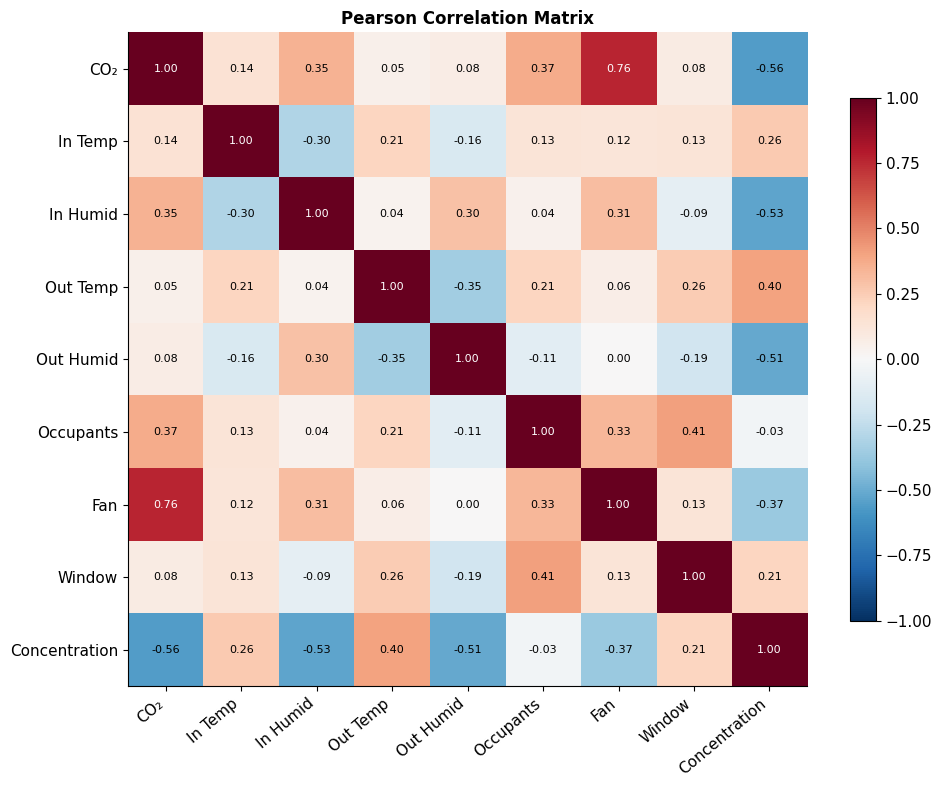

In [77]:

corr_cols = [
    'indoor_co2_ppm', 'indoor_temp_c', 'indoor_humidity_percent',
    'outdoor_temp_c', 'outdoor_humidity_percent',
    'number_of_occupants', 'fan_activation', 'window_open',
    'concentration_level'
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

labels = ['CO₂', 'In Temp', 'In Humid', 'Out Temp', 'Out Humid', 'Occupants', 'Fan', 'Window', 'Concentration']
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=40, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.iloc[i, j]
        text = 'NaN' if pd.isna(val) else f'{val:.2f}'
        ax.text(j, i, text, ha='center', va='center',
                fontsize=8, color='black' if (pd.isna(val) or abs(val) < 0.6) else 'white')

ax.set_title('Pearson Correlation Matrix', fontweight='bold')
plt.tight_layout()


## 10. Indoor vs outdoor temperature & humidity

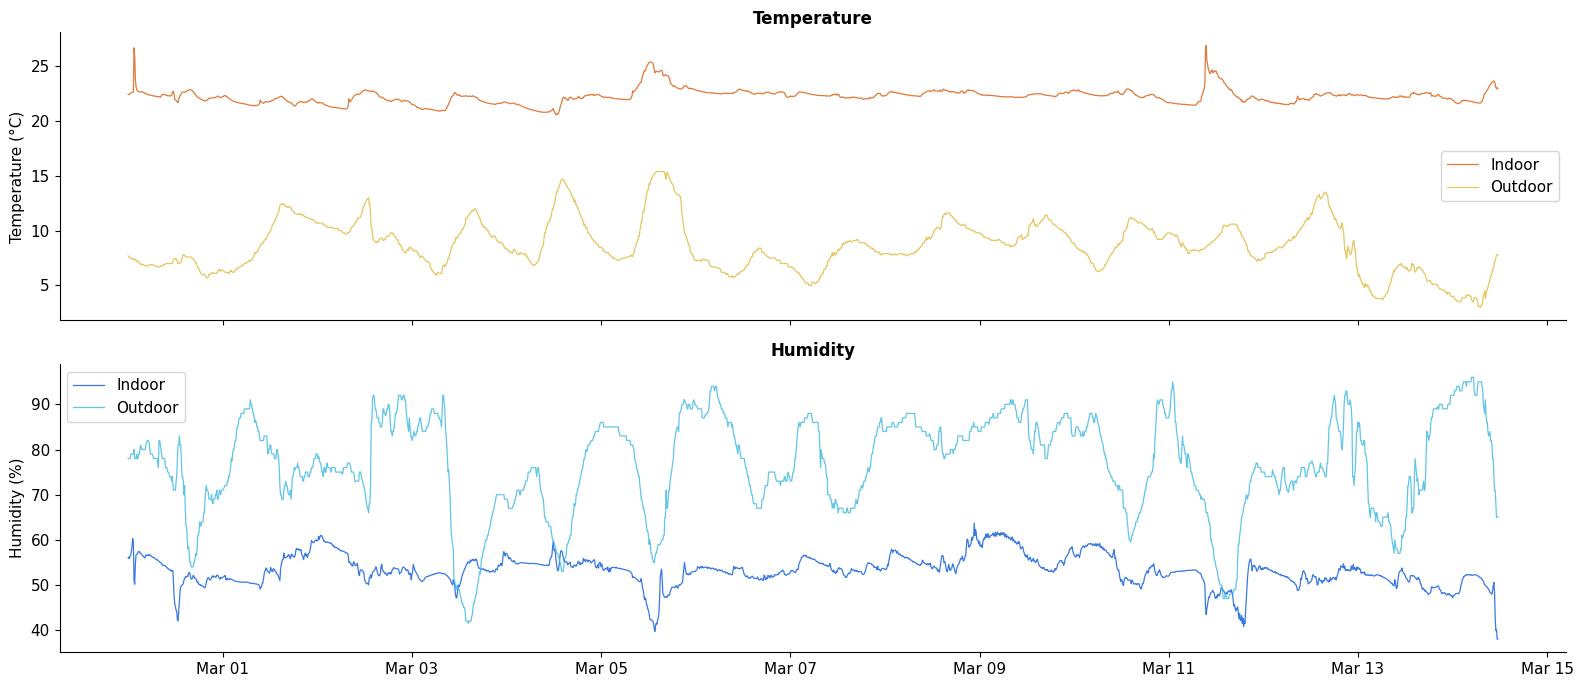

In [78]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

ax1.plot(df.index, df['indoor_temp_c'],   color='#e07a3a', linewidth=0.9, label='Indoor')
ax1.plot(df.index, df['outdoor_temp_c'],  color='#e0b83a', linewidth=0.9, label='Outdoor', alpha=0.8)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

ax2.plot(df.index, df['indoor_humidity_percent'],  color='#3a7ae0', linewidth=0.9, label='Indoor')
ax2.plot(df.index, df['outdoor_humidity_percent'], color='#3ab8e0', linewidth=0.9, label='Outdoor', alpha=0.8)
ax2.set_ylabel('Humidity (%)')
ax2.set_title('Humidity')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()

## 11. Occupancy & concentration

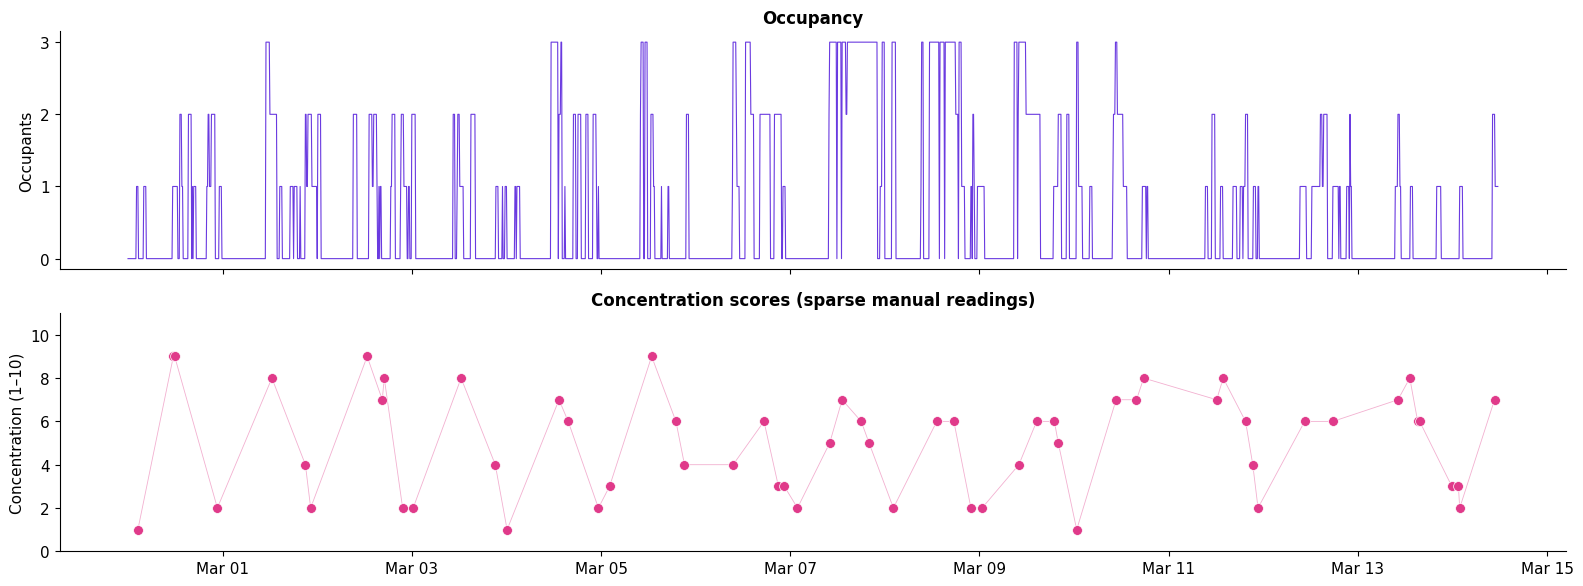

In [79]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

ax1.plot(df.index, df['number_of_occupants'], color='#6a3ae0', linewidth=0.8)
ax1.set_ylabel('Occupants')
ax1.set_title('Occupancy')
ax1.set_yticks([0, 1, 2, 3])
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

conc_plot = df[df['concentration_level'].notna()]
ax2.scatter(conc_plot.index, conc_plot['concentration_level'],
            color='#e03a8a', s=50, zorder=5, edgecolors='white', linewidths=0.5)
ax2.plot(conc_plot.index, conc_plot['concentration_level'],
         color='#e03a8a', linewidth=0.6, alpha=0.4)
ax2.set_ylabel('Concentration (1–10)')
ax2.set_title('Concentration scores (sparse manual readings)')
ax2.set_ylim(0, 11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()

## 12. Cross-correlation: CO₂ vs Indoor Humidity

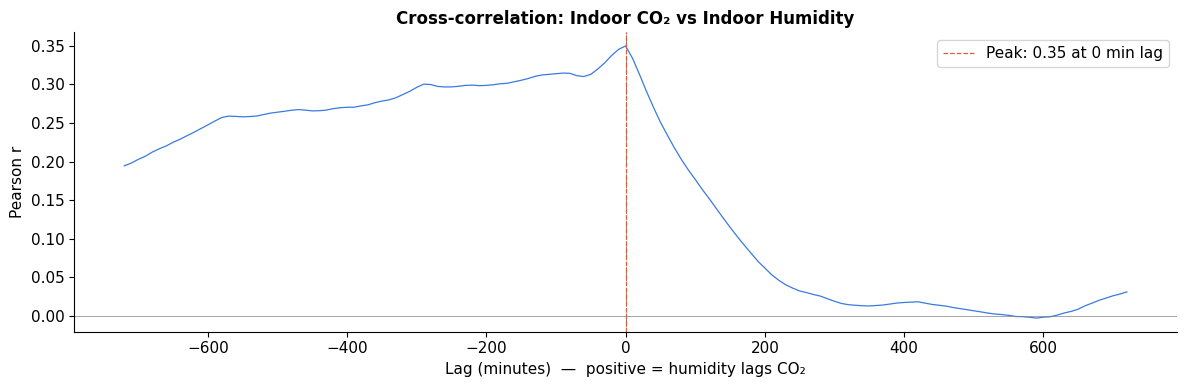

Peak correlation: r = 0.350 at lag = 0 min


In [80]:
import numpy as np

co2   = df['indoor_co2_ppm'].dropna()
humid = df['indoor_humidity_percent'].dropna()

# Align on common index
aligned = pd.concat([co2, humid], axis=1).dropna()
x = (aligned['indoor_co2_ppm']          - aligned['indoor_co2_ppm'].mean())
y = (aligned['indoor_humidity_percent'] - aligned['indoor_humidity_percent'].mean())

max_lag = 72  # 72 × 10min = 12 hours
lags = range(-max_lag, max_lag + 1)
xcorr = [x.corr(y.shift(lag)) for lag in lags]
lag_minutes = [l * 10 for l in lags]

peak_lag = lag_minutes[int(np.argmax(np.abs(xcorr)))]
peak_val  = xcorr[int(np.argmax(np.abs(xcorr)))]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lag_minutes, xcorr, color='#3a7ae0', linewidth=0.9)
ax.axvline(0, color='grey', linewidth=0.7, linestyle='--')
ax.axvline(peak_lag, color='#e05c3a', linewidth=0.9, linestyle='--',
           label=f'Peak: {peak_val:.2f} at {peak_lag} min lag')
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_xlabel('Lag (minutes)  —  positive = humidity lags CO₂')
ax.set_ylabel('Pearson r')
ax.set_title('Cross-correlation: Indoor CO₂ vs Indoor Humidity')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Peak correlation: r = {peak_val:.3f} at lag = {peak_lag} min")


## 15. Key Statistics for Results Paragraph

In [81]:
# --- 1. Baseline CO2 (occupancy = 0) ---
baseline   = df[df['number_of_occupants'] == 0]['indoor_co2_ppm']
single_occ = df[df['number_of_occupants'] == 1]['indoor_co2_ppm']
multi_occ  = df[df['number_of_occupants'] >= 2]['indoor_co2_ppm']

print("Baseline CO2 (0 occupants):")
print(f"  mean={baseline.mean():.0f} ppm,  median={baseline.median():.0f} ppm,  min={baseline.min():.0f} ppm")

print("\nCO2 with 1 occupant:")
print(f"  mean={single_occ.mean():.0f} ppm,  max={single_occ.max():.0f} ppm,  95th pct={single_occ.quantile(0.95):.0f} ppm")

print("\nCO2 with 2+ occupants:")
print(f"  mean={multi_occ.mean():.0f} ppm,  max={multi_occ.max():.0f} ppm,  95th pct={multi_occ.quantile(0.95):.0f} ppm")


window_opens = df[df['window_open'].diff() == 1].index
results = []
for t in window_opens:
    window = df.loc[t : t + pd.Timedelta(minutes=15), 'indoor_co2_ppm'].dropna()
    if len(window) >= 2:
        results.append({
            'start': window.iloc[0],
            'end':   window.iloc[-1],
            'drop':  window.iloc[0] - window.iloc[-1],
        })

if results:
    res = pd.DataFrame(results)
    print(f"\nVentilation events found: {len(res)}")
    print(f"  CO2 at window open:    mean={res['start'].mean():.0f} ppm")
    print(f"  CO2 15 min after open: mean={res['end'].mean():.0f} ppm")
    print(f"  Mean drop in 15 min:   {res['drop'].mean():.0f} ppm")
else:
    print("\nNo ventilation events detected — check window_open column")

# --- 3. Concentration scores vs CO2 bins ---
conc_data = df[df['concentration_level'].notna()][['indoor_co2_ppm', 'concentration_level']].copy()
bins   = [0, 800, 1000, 1200, 9999]
labels = ['<800', '800–1000', '1000–1200', '>1200']
conc_data['co2_bin'] = pd.cut(conc_data['indoor_co2_ppm'], bins=bins, labels=labels)
summary = conc_data.groupby('co2_bin', observed=True)['concentration_level'].agg(['mean', 'count'])
print("\nMean concentration score by CO2 bin:")
display(summary)

Baseline CO2 (0 occupants):
  mean=841 ppm,  median=839 ppm,  min=468 ppm

CO2 with 1 occupant:
  mean=903 ppm,  max=1624 ppm,  95th pct=1296 ppm

CO2 with 2+ occupants:
  mean=1055 ppm,  max=1989 ppm,  95th pct=1429 ppm

Ventilation events found: 23
  CO2 at window open:    mean=1236 ppm
  CO2 15 min after open: mean=1133 ppm
  Mean drop in 15 min:   103 ppm

Mean concentration score by CO2 bin:


,mean,count
co2_bin,,
<800,7.200000,15
800–1000,4.882353,17
1000–1200,4.300000,20
>1200,2.857143,7


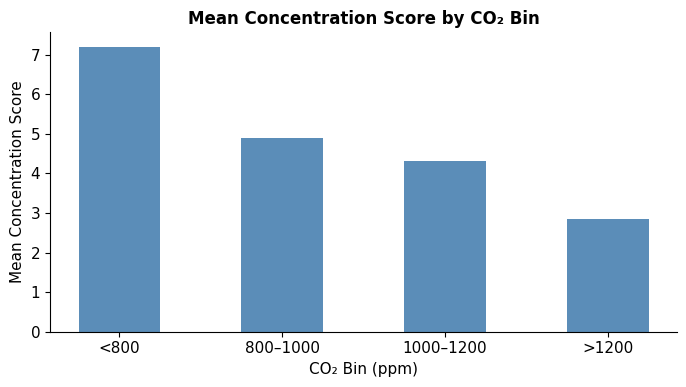

In [82]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary.index.astype(str), summary['mean'], color='#5b8db8', width=0.5)
ax.set_xlabel('CO₂ Bin (ppm)')
ax.set_ylabel('Mean Concentration Score')
ax.set_title('Mean Concentration Score by CO₂ Bin')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

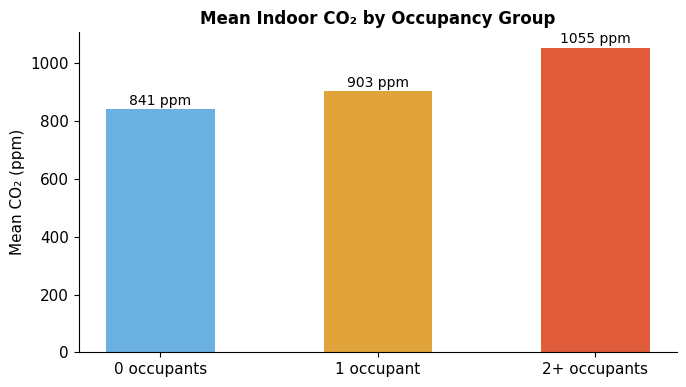

In [83]:
groups = ['0 occupants', '1 occupant', '2+ occupants']
means  = [
    df[df['number_of_occupants'] == 0]['indoor_co2_ppm'].mean(),
    df[df['number_of_occupants'] == 1]['indoor_co2_ppm'].mean(),
    df[df['number_of_occupants'] >= 2]['indoor_co2_ppm'].mean(),
]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(groups, means, color=['#6ab0e0', '#e0a43a', '#e05c3a'], width=0.5)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 5,
            f'{val:.0f} ppm', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Mean CO₂ (ppm)')
ax.set_title('Mean Indoor CO₂ by Occupancy Group')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 17. Ventilation Events — CO₂ Drop Table

In [84]:
# Build ventilation event table (one row per window-open period)
opens  = df[df['window_open'].diff() ==  1].index
closes = df[df['window_open'].diff() == -1].index

rows = []
for t_open in opens:
    future_closes = closes[closes > t_open]
    t_close = future_closes[0] if len(future_closes) > 0 else df.index[-1]

    period = df.loc[t_open:t_close, 'indoor_co2_ppm'].dropna()
    if len(period) < 2:
        continue

    co2_start    = period.iloc[0]
    co2_end      = period.iloc[-1]
    duration_min = (t_close - t_open).total_seconds() / 60
    total_drop   = co2_start - co2_end

    first_15 = df.loc[t_open : t_open + pd.Timedelta(minutes=15), 'indoor_co2_ppm'].dropna()
    drop_per_min = (first_15.iloc[0] - first_15.iloc[-1]) / 15 if len(first_15) >= 2 else float('nan')

    rows.append({
        'window_open':      t_open.strftime('%Y-%m-%d %H:%M'),
        'window_close':     t_close.strftime('%Y-%m-%d %H:%M'),
        'duration_min':     round(duration_min),
        'co2_start_ppm':    round(co2_start),
        'co2_end_ppm':      round(co2_end),
        'total_drop_ppm':   round(total_drop),
        'drop_per_min_ppm': round(drop_per_min, 1),
    })

vent_df = pd.DataFrame(rows)
vent_df = vent_df[vent_df['total_drop_ppm'] > 0].reset_index(drop=True)

display(vent_df)

valid_rate = vent_df[vent_df['drop_per_min_ppm'] > 0]['drop_per_min_ppm']
means = vent_df[['duration_min', 'co2_start_ppm', 'co2_end_ppm', 'total_drop_ppm']].mean().round(1)
means['drop_per_min_ppm'] = round(valid_rate.mean(), 1)
print(f"\nMean across {len(vent_df)} events (drop_per_min from {len(valid_rate)} valid):")
display(means)

,window_open,window_close,duration_min,co2_start_ppm,co2_end_ppm,total_drop_ppm,drop_per_min_ppm
0,2026-02-28 11:40,2026-02-28 13:00,80,708,558,150,6.3
1,2026-03-01 11:00,2026-03-01 18:20,440,1083,611,472,0.6
2,2026-03-02 10:10,2026-03-02 12:50,160,925,615,310,5.7
3,2026-03-03 10:30,2026-03-03 11:50,80,1489,1152,338,17.7
4,2026-03-03 16:20,2026-03-03 19:30,190,1492,825,667,7.9
5,2026-03-04 11:50,2026-03-04 13:10,80,1511,717,795,21.0
6,2026-03-04 16:00,2026-03-04 18:10,130,1213,1065,148,1.4
7,2026-03-04 22:20,2026-03-05 01:10,170,1403,870,533,13.3
8,2026-03-05 10:00,2026-03-05 13:40,220,1031,525,506,-35.1
9,2026-03-06 09:40,2026-03-06 13:10,210,1989,1064,925,15.9



Mean across 21 events (drop_per_min from 19 valid):


duration_min         206.2
co2_start_ppm       1276.8
co2_end_ppm          804.7
total_drop_ppm       472.0
drop_per_min_ppm       9.6
dtype: float64

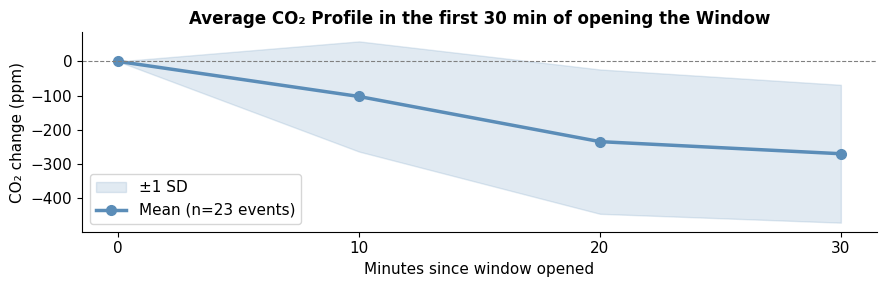

In [85]:
# Average CO₂ profile during first 30 min of each window-open event
WINDOW_MIN = 30

profiles = []
for t_open in opens:
    t_end = t_open + pd.Timedelta(minutes=WINDOW_MIN)
    segment = df.loc[t_open:t_end, 'indoor_co2_ppm'].dropna()
    if len(segment) < 2:
        continue
    rel_min = [(t - t_open).total_seconds() / 60 for t in segment.index]
    profiles.append(pd.Series(segment.values, index=rel_min))

# Align onto a common time axis and normalise to CO₂ at window-open
common_t = np.arange(0, WINDOW_MIN + 1, 10)
aligned = pd.DataFrame(
    {i: np.interp(common_t, p.index, p.values) for i, p in enumerate(profiles)},
    index=common_t
).T
aligned = aligned.subtract(aligned[0], axis=0)   # change relative to t=0

mean_p = aligned.mean()
std_p  = aligned.std()

fig, ax = plt.subplots(figsize=(9, 3))
ax.fill_between(common_t, mean_p - std_p, mean_p + std_p,
                alpha=0.18, color='#5b8db8', label='±1 SD')
ax.plot(common_t, mean_p, color='#5b8db8', linewidth=2.5,
        marker='o', markersize=7, label=f'Mean (n={len(profiles)} events)')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xticks(common_t)
ax.set_xlabel('Minutes since window opened')
ax.set_ylabel('CO₂ change (ppm)')
ax.set_title('Average CO₂ Profile in the first 30 min of opening the Window')
ax.legend()
plt.tight_layout()
plt.show()